# Análisis de Paquetes de Red
Detección de anomalías en tráfico de red usando Z-score e Isolation Forest.

## Dependencias

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scapy.all import rdpcap, IP, UDP, TCP, Raw
from sklearn.ensemble import IsolationForest

## Testeo de la herramienta

In [14]:
pcap_file = "analisis_paquetes.pcap"
packets = rdpcap(pcap_file)

print("Tipo de dato:", type(packets))
print("Cantidad de paquetes:", len(packets))
print("Primeros 10 paquetes:\n")

for i, pkt in enumerate(packets[:10], start=1):
    print(f"Paquete {i}")
    print("Longitud:", len(pkt))
    print(pkt.summary())
    print(bytes(pkt)[:80])  # primeros bytes
    print("-" * 60)

Tipo de dato: <class 'scapy.plist.PacketList'>
Cantidad de paquetes: 62
Primeros 10 paquetes:

Paquete 1
Longitud: 975
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
b'\x807s\x96\x9b\xdb\x88\xe9\xfej\x92R\x08\x00E\x00\x03\xc1\x00\x01\x00\x00@\x11R\xe6\n\x01\n5T6\x16!\x005\x005\x03\xad\xf6\x0e\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00\x00\x06google\x03com\x00\x00\x1c\x00\x01\xef\xbf\xbdPNG\r\n\x1a\n'
------------------------------------------------------------
Paquete 2
Longitud: 98
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
b"\x88\xe9\xfej\x92R\x807s\x96\x9b\xdb\x08\x00E \x00T\xe6'\x00\x00z\x116\x0cT6\x16!\n\x01\n5\x005\x005\x00@\xfe%\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00\x00\x06google\x03com\x00\x00\x1c\x00\x01\xc0\x0c\x00\x1c\x00\x01\x00\x00\x01+"
------------------------------------------------------------
Paquete 3
Longitud: 989
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
b'\x807s\x96\x9b\xdb\x88\xe9\xfej\x92R\x08\x00E\x00\x03\xcf\x00\x01\x00\x00@\x11R\xd8\n\x

## Estadísticas y detección con Z-Score

In [15]:
rows = []

for i, pkt in enumerate(packets, start=1):
    row = {
        "packet_no": i,
        "src_ip": None,
        "dst_ip": None,
        "src_port": None,
        "dst_port": None,
        "proto": None,
        "pkt_len": len(pkt),
        "payload": b"",
        "payload_len": 0
    }

    if IP in pkt:
        row["src_ip"] = pkt[IP].src
        row["dst_ip"] = pkt[IP].dst
        row["proto"] = pkt[IP].proto

    if UDP in pkt:
        row["src_port"] = pkt[UDP].sport
        row["dst_port"] = pkt[UDP].dport
        row["proto"] = "UDP"
        payload = bytes(pkt[UDP].payload)
        row["payload"] = payload
        row["payload_len"] = len(payload)

    elif TCP in pkt:
        row["src_port"] = pkt[TCP].sport
        row["dst_port"] = pkt[TCP].dport
        row["proto"] = "TCP"
        payload = bytes(pkt[TCP].payload)
        row["payload"] = payload
        row["payload_len"] = len(payload)

    rows.append(row)

df = pd.DataFrame(rows)
df.head()

,packet_no,src_ip,dst_ip,src_port,dst_port,proto,pkt_len,payload,payload_len
0,1,10.1.10.53,84.54.22.33,53,53,UDP,975,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,933
1,2,84.54.22.33,10.1.10.53,53,53,UDP,98,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,56
2,3,10.1.10.53,84.54.22.33,53,53,UDP,989,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,947
3,4,84.54.22.33,10.1.10.53,53,53,UDP,98,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,56
4,5,10.1.10.53,84.54.22.33,53,53,UDP,1026,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,984


In [16]:
df[["src_ip", "dst_ip", "src_port", "dst_port"]].head(10)

,src_ip,dst_ip,src_port,dst_port
0,10.1.10.53,84.54.22.33,53,53
1,84.54.22.33,10.1.10.53,53,53
2,10.1.10.53,84.54.22.33,53,53
3,84.54.22.33,10.1.10.53,53,53
4,10.1.10.53,84.54.22.33,53,53
5,84.54.22.33,10.1.10.53,53,53
6,10.1.10.53,84.54.22.33,53,53
7,84.54.22.33,10.1.10.53,53,53
8,10.1.10.53,84.54.22.33,53,53
9,84.54.22.33,10.1.10.53,53,53


In [17]:
src_ip_mas_frecuente = df["src_ip"].value_counts().idxmax()
dst_ip_mas_frecuente = df["dst_ip"].value_counts().idxmax()

print("IP origen más frecuente:", src_ip_mas_frecuente)
print("IP destino más frecuente:", dst_ip_mas_frecuente)

ips_comunicadas = df[df["src_ip"] == src_ip_mas_frecuente]["dst_ip"].value_counts()
print("\nIPs a las que se comunica la IP origen más frecuente:")
print(ips_comunicadas)

puertos_destino = df[df["src_ip"] == src_ip_mas_frecuente]["dst_port"].value_counts()
print("\nPuertos destino a los que se comunica la IP origen más frecuente:")
print(puertos_destino)

puertos_origen = df[df["dst_ip"] == dst_ip_mas_frecuente]["src_port"].value_counts()
print("\nPuertos origen que se comunican con la IP destino más frecuente:")
print(puertos_origen)

IP origen más frecuente: 10.1.10.53
IP destino más frecuente: 10.1.10.53

IPs a las que se comunica la IP origen más frecuente:
dst_ip
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64

Puertos destino a los que se comunica la IP origen más frecuente:
dst_port
53    31
Name: count, dtype: int64

Puertos origen que se comunican con la IP destino más frecuente:
src_port
53    31
Name: count, dtype: int64


In [18]:
media_payload = df["payload_len"].mean()
std_payload = df["payload_len"].std()

df["zscore_payload"] = (df["payload_len"] - media_payload) / std_payload

anomalias_z2 = df[df["zscore_payload"].abs() > 2]
anomalias_z3 = df[df["zscore_payload"].abs() > 3]

print("Media payload:", media_payload)
print("Desviación estándar:", std_payload)
print("\nPaquetes con |Z| > 2:")
print(anomalias_z2[["packet_no", "src_ip", "dst_ip", "src_port", "dst_port", "payload_len", "zscore_payload"]])

print("\nPaquetes con |Z| > 3:")
print(anomalias_z3[["packet_no", "src_ip", "dst_ip", "src_port", "dst_port", "payload_len", "zscore_payload"]])

Media payload: 481.33870967741933
Desviación estándar: 460.2700185243507

Paquetes con |Z| > 2:
Empty DataFrame
Columns: [packet_no, src_ip, dst_ip, src_port, dst_port, payload_len, zscore_payload]
Index: []

Paquetes con |Z| > 3:
Empty DataFrame
Columns: [packet_no, src_ip, dst_ip, src_port, dst_port, payload_len, zscore_payload]
Index: []


### Análisis — Inciso 4b

La distribución de payload_len no es normal. Presenta un comportamiento bimodal o mixto, con un grupo de paquetes pequeños y otro grupo de paquetes muy grandes. Debido a esto, la media y la desviación estándar calculadas directamente del pcap no representan bien el comportamiento normal del protocolo, por lo que el Z-score tradicional no detecta anomalías.

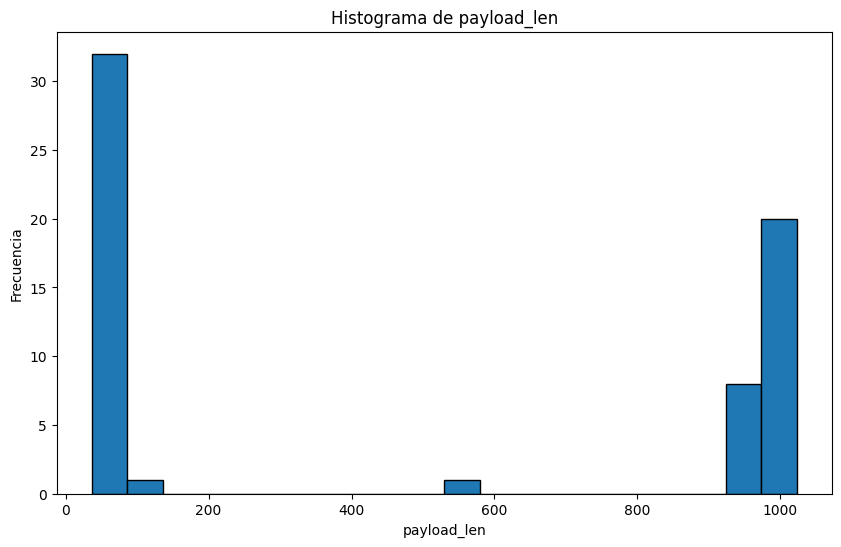

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(df["payload_len"], bins=20, edgecolor="black")
plt.xlabel("payload_len")
plt.ylabel("Frecuencia")
plt.title("Histograma de payload_len")
plt.show()

In [20]:
media_dns = 50
std_dns = 15

df["zscore_dns_ref"] = (df["payload_len"] - media_dns) / std_dns

anomalias_dns = df[df["zscore_dns_ref"].abs() > 2]
anomalias_dns_3 = df[df["zscore_dns_ref"].abs() > 3]

print("Paquetes detectados con referencia DNS y |Z| > 2:")
print(anomalias_dns[["packet_no", "src_ip", "dst_ip", "src_port", "dst_port", "payload_len", "zscore_dns_ref"]])
print("\nCantidad:", len(anomalias_dns))

print("\nPaquetes detectados con referencia DNS y |Z| > 3:")
print(anomalias_dns_3[["packet_no", "src_ip", "dst_ip", "src_port", "dst_port", "payload_len", "zscore_dns_ref"]])
print("\nCantidad:", len(anomalias_dns_3))

Paquetes detectados con referencia DNS y |Z| > 2:
    packet_no       src_ip       dst_ip  src_port  dst_port  payload_len  \
0           1   10.1.10.53  84.54.22.33        53        53          933   
2           3   10.1.10.53  84.54.22.33        53        53          947   
4           5   10.1.10.53  84.54.22.33        53        53          984   
6           7   10.1.10.53  84.54.22.33        53        53          970   
8           9   10.1.10.53  84.54.22.33        53        53          975   
10         11   10.1.10.53  84.54.22.33        53        53         1017   
12         13   10.1.10.53  84.54.22.33        53        53          980   
14         15   10.1.10.53  84.54.22.33        53        53          951   
16         17   10.1.10.53  84.54.22.33        53        53          931   
18         19   10.1.10.53  84.54.22.33        53        53          964   
20         21   10.1.10.53  84.54.22.33        53        53         1023   
25         26  75.75.75.75   10.1.10.5

### Análisis — Inciso 4d

Este resultado demuestra que las técnicas de detección de anomalías dependen del contexto del protocolo. Usar conocimiento de dominio sobre DNS permitió detectar paquetes anómalos que no fueron visibles con una normalización basada únicamente en los datos del pcap.

## Gráficas

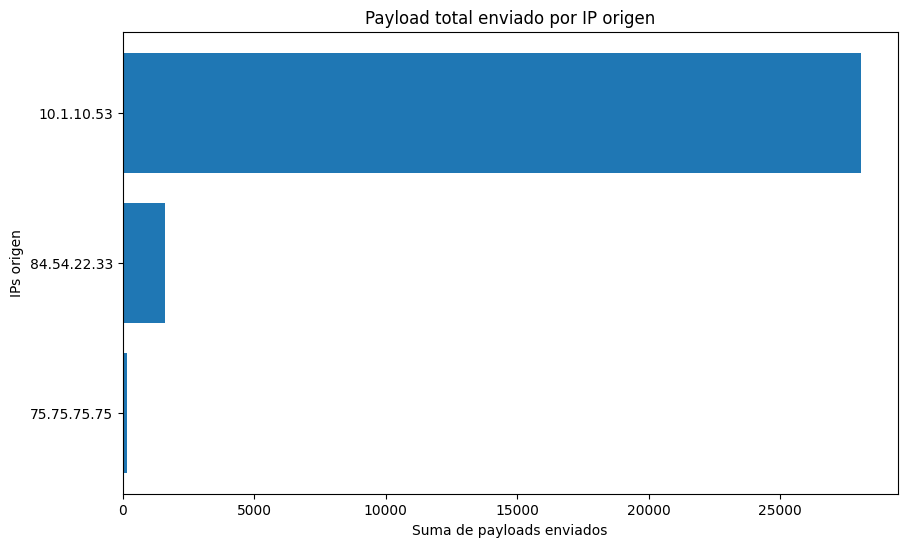

In [21]:
# a) Suma payload por IP origen
src_payload = df.groupby("src_ip")["payload_len"].sum().sort_values()
plt.figure(figsize=(10, 6))
plt.barh(src_payload.index, src_payload.values)
plt.xlabel("Suma de payloads enviados")
plt.ylabel("IPs origen")
plt.title("Payload total enviado por IP origen")
plt.show()

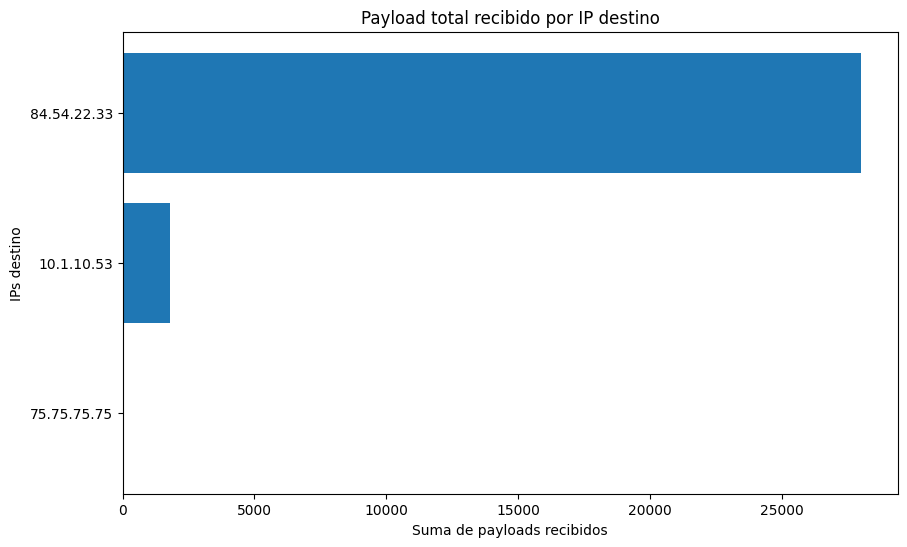

In [ ]:
dst_payload = df.groupby("dst_ip")["payload_len"].sum().sort_values()
plt.figure(figsize=(10, 6))
plt.barh(dst_payload.index, dst_payload.values)
plt.xlabel("Suma de payloads recibidos")
plt.ylabel("IPs destino")
plt.title("Payload total recibido por IP destino")
plt.show()

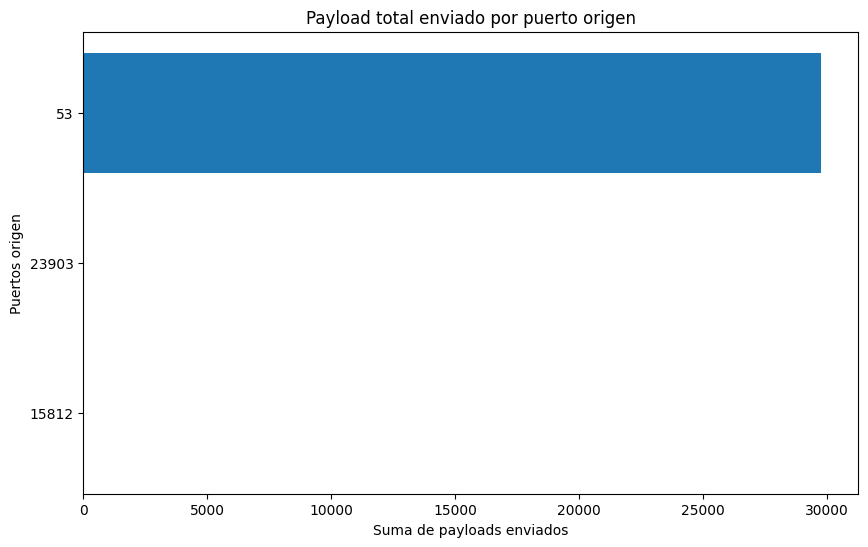

In [ ]:
sport_payload = df.groupby("src_port")["payload_len"].sum().sort_values()
plt.figure(figsize=(10, 6))
plt.barh(sport_payload.index.astype(str), sport_payload.values)
plt.xlabel("Suma de payloads enviados")
plt.ylabel("Puertos origen")
plt.title("Payload total enviado por puerto origen")
plt.show()

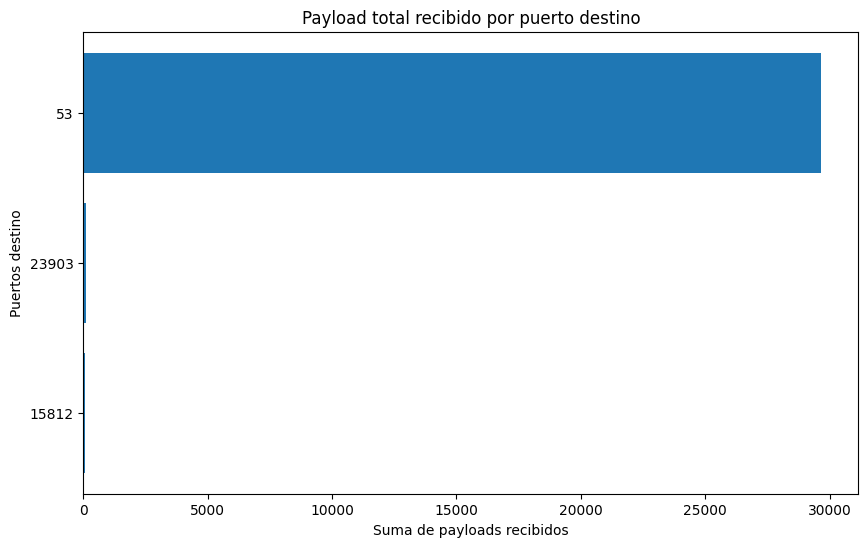

In [ ]:
dport_payload = df.groupby("dst_port")["payload_len"].sum().sort_values()
plt.figure(figsize=(10, 6))
plt.barh(dport_payload.index.astype(str), dport_payload.values)
plt.xlabel("Suma de payloads recibidos")
plt.ylabel("Puertos destino")
plt.title("Payload total recibido por puerto destino")
plt.show()

## Detección automática con Isolation Forest

In [25]:
X = df[["payload_len", "pkt_len"]].copy()

contamination_value = len(anomalias_dns) / len(df)
print("Contamination:", contamination_value)

iso = IsolationForest(contamination=contamination_value, random_state=42)
df["iforest_pred"] = iso.fit_predict(X)

anomalias_iforest = df[df["iforest_pred"] == -1]

print(anomalias_iforest[["packet_no", "src_ip", "dst_ip", "src_port", "dst_port", "payload_len", "pkt_len"]])

Contamination: 0.4838709677419355
    packet_no       src_ip       dst_ip  src_port  dst_port  payload_len  \
0           1   10.1.10.53  84.54.22.33        53        53          933   
2           3   10.1.10.53  84.54.22.33        53        53          947   
4           5   10.1.10.53  84.54.22.33        53        53          984   
6           7   10.1.10.53  84.54.22.33        53        53          970   
8           9   10.1.10.53  84.54.22.33        53        53          975   
10         11   10.1.10.53  84.54.22.33        53        53         1017   
12         13   10.1.10.53  84.54.22.33        53        53          980   
14         15   10.1.10.53  84.54.22.33        53        53          951   
16         17   10.1.10.53  84.54.22.33        53        53          931   
18         19   10.1.10.53  84.54.22.33        53        53          964   
20         21   10.1.10.53  84.54.22.33        53        53         1023   
22         23   10.1.10.53  75.75.75.75     15812     

### Análisis — Inciso 6b

Las anomalías detectadas por Isolation Forest coinciden en gran parte con la conversación sospechosa entre 10.1.10.53 y 84.54.22.33, pero también incluyen algunos paquetes DNS legítimos, probablemente debido al valor alto de contamination y al tamaño reducido del conjunto de datos.

## Investigación del payload (confirmación manual)

In [ ]:
df_src_frecuente = df[df["src_ip"] == src_ip_mas_frecuente].copy()

df_payload_grouped = (
    df_src_frecuente.groupby(["src_ip", "dst_ip", "payload_len"])
    .size()
    .reset_index(name="count")
)

df_payload_grouped.head()

,src_ip,dst_ip,payload_len,count
0,10.1.10.53,75.75.75.75,37,2
1,10.1.10.53,84.54.22.33,560,1
2,10.1.10.53,84.54.22.33,931,1
3,10.1.10.53,84.54.22.33,933,1
4,10.1.10.53,84.54.22.33,941,1


In [ ]:
df_src_or_dst = df[(df["src_ip"] == src_ip_mas_frecuente) | (df["dst_ip"] == src_ip_mas_frecuente)].copy()

df_src_or_dst["peer_ip"] = np.where(
    df_src_or_dst["src_ip"] == src_ip_mas_frecuente,
    df_src_or_dst["dst_ip"],
    df_src_or_dst["src_ip"]
)

peer_bytes = df_src_or_dst.groupby("peer_ip")["payload_len"].sum().sort_values(ascending=False)
print(peer_bytes)

peer_ip
84.54.22.33    29603
75.75.75.75      240
Name: payload_len, dtype: int64


In [ ]:
ip_sospechosa = peer_bytes.idxmax()

df_conversacion = df[
    ((df["src_ip"] == src_ip_mas_frecuente) & (df["dst_ip"] == ip_sospechosa)) |
    ((df["src_ip"] == ip_sospechosa) & (df["dst_ip"] == src_ip_mas_frecuente))
].copy()

df_conversacion[["packet_no", "src_ip", "dst_ip", "src_port", "dst_port", "payload_len"]]

,packet_no,src_ip,dst_ip,src_port,dst_port,payload_len
0,1,10.1.10.53,84.54.22.33,53,53,933
1,2,84.54.22.33,10.1.10.53,53,53,56
2,3,10.1.10.53,84.54.22.33,53,53,947
3,4,84.54.22.33,10.1.10.53,53,53,56
4,5,10.1.10.53,84.54.22.33,53,53,984
5,6,84.54.22.33,10.1.10.53,53,53,56
6,7,10.1.10.53,84.54.22.33,53,53,970
7,8,84.54.22.33,10.1.10.53,53,53,56
8,9,10.1.10.53,84.54.22.33,53,53,975
9,10,84.54.22.33,10.1.10.53,53,53,56


In [ ]:
payload_array = df_conversacion["payload"].tolist()

print(payload_array[0])
print(payload_array[0][:100])

b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00\x00\x06google\x03com\x00\x00\x1c\x00\x01\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01b\x00\x00\x00\xef\xbf\xbd\x08\x06\x00\x00\x00(\xef\xbf\xbdTR\x00\x00:\xef\xbf\xbdIDATx\xef\xbf\xbd\xef\xbf\xbd\t|T\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd;K\x12\x08;\x08\xef\xbf\xbd\nE\xef\xbf\xbd\xef\xbf\xbd$\x19\xef\xbf\xbd\xef\xbf\xbdZi\xdf\xaa-\xef\xbf\xbd;N2\xef\xbf\xbd\xef\xbf\xbdV\xef\xbf\xbdV\xef\xbf\xbda\xef\xbf\xbdZ\x11!\xef\xbf\xbd\xef\xbf\xbd\x01\xdc\xbbik[\xef\xbf\xbd.ok\xef\xbf\xbde\xef\xbf\xbd\x01\\\xef\xbf\xbd\xef\xbf\xbd]\xef\xbf\xbd-\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbdd\xef\xbf\xbd\x08\xef\xbf\xbd\x08\xef\xbf\xbd\xef\xbf\xbdg\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd<\xef\xbf\xbd\xef\xbf\xbdL\x12\xef\xbf\xbd$3wf\xef\xbf\xbd\xef\xbf\xbd\x02<_\r\xef\xbf\xbdY\xef\xbf\xbdr\xef\xbf\xbd\xef\xbf\xbdy\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\x1c\r\x18\xef\xbf\xbd8c\xef\xbf\xbdew\r\x1e\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf

In [30]:
# g) Primeros bytes en hex
print(payload_array[0][:64].hex())

000c0100000100000000000006676f6f676c6503636f6d00001c0001efbfbd504e470d0a1a0a0000000d4948445200000162000000efbfbd080600000028efbf


### Análisis — Inciso 7g

Al inspeccionar manualmente el payload, se observa que el tráfico contiene una estructura inicial similar a una consulta DNS, pero también incluye datos binarios que no corresponden al uso normal del puerto 53, incluyendo firmas asociadas a contenido PNG. Esto sugiere un ataque de DNS tunneling o exfiltración de datos disfrazado como tráfico DNS. La combinación de técnicas automáticas con revisión manual del payload es importante porque los métodos automáticos detectan desviaciones estadísticas, pero la inspección manual confirma la naturaleza real del ataque.